# Data Science for Business - Tree-based Models on Micro Mortgages

## Initialize notebook
Load required packages. Set up workspace, e.g., set theme for plotting and initialize the random number generator.

In [1]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay, auc
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier


In [2]:
np.random.seed(42)
plt.style.use('fivethirtyeight')

## Problem description

In India, there are about 20 million home loan (mortgage) aspirants
working in the informal sector:

- Monthly income between INR 20,000-25,000 (\$ 325-400)
- Typically no formal accounts and documents (e.g., tax returns, income proofs, bank statements)
- Often use services of money lenders with interest rates between 30 and 60% per annum

Providing mortgages to this group of customers requires to quickly and
efficiently assess their creditworthiness. Due to a lack of formal
documents and objective data, most financial institutions perform
interview-based processes to decide about these loan requests:

Strength of the current process:

-   Interview-based field assessment

-   Relaxation of document requirements

Weaknesses of the current process:

-   Costly (total transaction costs as high as 30% of loan volume)

-   Subjective judgments; depends on individual skills and motivations

-   Low reliability across branches and credit officers

-   Risk of corruption and fraud

## Load data

Load training data from CSV file.

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/olivermueller/ds4b-2024/refs/heads/main/Session_07/micromortgage.csv')

In [6]:
data.head()

,Decision,Build_Selfcon,Tier,Accommodation_Class,Loan_Type,Gender,Employment_Type,Doc_Proof_Inc,Marital_Status,Employer_Type,...,LoanReq,Term,Dwnpay,BankSave,CalcEmi,IIR,IAR,FOIR,LTV,LVR
0,1,Self Contruction,T2,Non_Rented,Home_Loan,Female,Salaried,N,Married,Corporate,...,780000,180,670000,0,12004.230470,34.999797,45.000114,34.999797,80.000000,54.000000
1,0,Self Contruction,T1,Non_Rented,Home_Loan,Female,Self_Employed,N,Married,Business,...,800000,180,470000,0,12312.030270,49.248121,75.533928,49.248121,62.992126,62.992126
2,1,Self Contruction,T3,Rented,Home_Loan,Female,Salaried,N,Married,Corporate,...,480000,120,120000,300000,8342.290039,41.999144,79.998946,41.999144,78.999992,80.000000
3,1,Self Contruction,T3,Non_Rented,Home_Loan,Female,Self_Employed,N,Married,Business,...,300000,180,95000,0,4617.009766,30.999126,84.996498,30.999126,20.000000,76.000000
4,0,Self Contruction,T2,Non_Rented,Home_Loan,Female,Self_Employed,N,Married,Business,...,1000000,180,375000,0,15390.040040,45.000117,57.999020,45.000117,73.000001,73.000000


## Prepare data

Do some harmless data preparation steps.

In [5]:
data = data.drop(['ID'], axis=1)
data["Tier"] = data["Tier"].apply(lambda x: "T"+str(x))

Split data into X and y and train and test sets.

In [7]:
X = data.drop("Decision", axis=1)
y = data["Decision"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Preprocess categorical features using one-hot encoding and numerical features using standard scaling.

In [8]:
categorical_features = X_train.select_dtypes(include='object').columns
numerical_features = X_train.select_dtypes(exclude='object').columns

In [11]:
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
enc.fit(X_train[categorical_features])

X_train_cat = enc.transform(X_train[categorical_features])
X_test_cat = enc.transform(X_test[categorical_features])

X_train_cat = pd.DataFrame(X_train_cat, columns=enc.get_feature_names_out(categorical_features))
X_test_cat = pd.DataFrame(X_test_cat, columns=enc.get_feature_names_out(categorical_features))

In [12]:
scaler = StandardScaler()
scaler.fit(X_train[numerical_features]) 

X_train_num = scaler.transform(X_train[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

X_train_num = pd.DataFrame(X_train_num, columns=numerical_features)
X_test_num = pd.DataFrame(X_test_num, columns=numerical_features)

In [13]:
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

## Classification and Regression Trees (CART)

First, we will grow a single CART tree.

In [19]:
model_cart = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)

In [20]:
model_cart.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

Let's check how well the tree performs on the training and test data.

In [21]:
# Training data
pred_label_train = model_cart.predict(X_train)
pred_proba_train = model_cart.predict_proba(X_train)[:,1]
acc_train = accuracy_score(y_train, pred_label_train)
auc_train = roc_auc_score(y_train, pred_proba_train)
print('ACC on training set:', round(acc_train, 2))
print('AUC on training set:', round(auc_train, 2))

print("===")

# Test data
pred_label_test = model_cart.predict(X_test)
pred_proba_test = model_cart.predict_proba(X_test)[:,1]
acc_test = accuracy_score(y_test, pred_label_test)
auc_test = roc_auc_score(y_test, pred_proba_test)
print('ACC on test set:', round(acc_test, 2))
print('AUC on test set:', round(auc_test, 2))

ACC on training set: 0.84
AUC on training set: 0.74
===
ACC on test set: 0.81
AUC on test set: 0.66


The advantage of a single tree is that it is easy to interpret and visualize. Let's have a look.

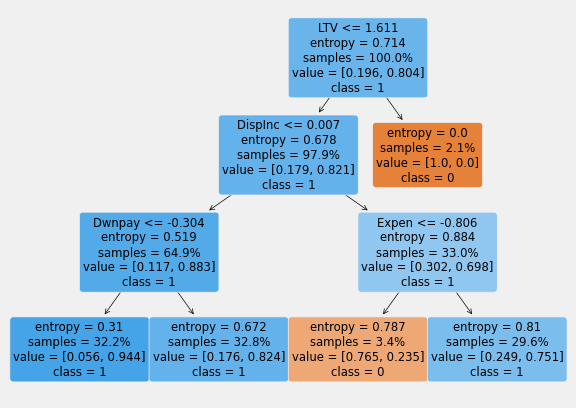

In [22]:
fn = model_cart.feature_names_in_
labels = model_cart.classes_
labels = [str(item) for item in labels]

tree.plot_tree(model_cart, feature_names=fn, class_names=labels, filled=True, proportion=True, rounded=True)
plt.show()

Wow, that's a big tree! It is hard to interpret and understand. Let's go back and try to grow a smaller tree by setting stopping rules (e.g., `max_depth`) or pruning the tree (`ccp_alpha`).

In [ ]:
# YOUR CODE HERE


## Random Forest

Let's now try to grow a random forest. We use grid search for hyperparameter tuning with k-fold cross validation to find the best model.

In [23]:
model_rf_cv = lambda: GridSearchCV(
                estimator=RandomForestClassifier(random_state=42),
                param_grid={
                        'n_estimators': [100, 200, 300, 400, 500],
                        'max_depth': [3, 5, None],
                        'min_samples_leaf': [2, 5, 10]
                    }, cv=5, n_jobs=-1
                )

In [24]:
model_rf_tuned = model_rf_cv()
model_rf_tuned.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, None],
                         'min_samples_leaf': [2, 5, 10],
                         'n_estimators': [100, 200, 300, 400, 500]})

In [25]:
model_rf_tuned.best_estimator_

RandomForestClassifier(min_samples_leaf=2, n_estimators=500, random_state=42)

Make predictions on test set and evaluate the model.

In [26]:
rf_pred_label = model_rf_tuned.predict(X_test)
rf_pred_proba = model_rf_tuned.predict_proba(X_test)[:,1]

Display precision, recall, F1-Score and accuracy.

In [27]:
print(classification_report(y_test, rf_pred_label))

              precision    recall  f1-score   support

           0       1.00      0.33      0.49        55
           1       0.84      1.00      0.91       197

    accuracy                           0.85       252
   macro avg       0.92      0.66      0.70       252
weighted avg       0.88      0.85      0.82       252



Plot the ROC curve and calculate the AUC.

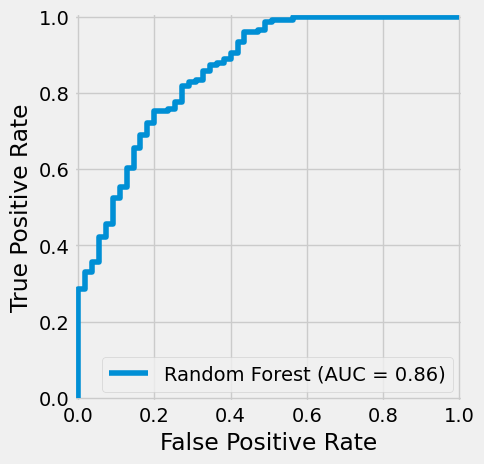

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, rf_pred_proba)
auc_score = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score, estimator_name='Random Forest')
display.plot()
plt.show()

## Boosted Trees

Finally, we will try boosted trees. We will use the fast `HistGradientBoostingClassifier` (Histogram-based Gradient Boosting Classification Tree) learner, which is inspired by the LightGBM algorithm. Again, we will use hyperparameter tuning with k-fold cross validation to find the best model.

In [29]:
model_boost_cv = lambda: GridSearchCV(
                estimator=HistGradientBoostingClassifier(random_state=42),
                param_grid={
                        'max_iter': [100, 200, 300, 400, 500, 1000, 2000, 3000],
                        'max_depth': [1, 3, 5]
                    }, cv=5, n_jobs=-1
                )

In [30]:
model_boost_tuned = model_boost_cv()
model_boost_tuned.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=HistGradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [1, 3, 5],
                         'max_iter': [100, 200, 300, 400, 500, 1000, 2000,
                                      3000]})

In [33]:
model_boost_tuned.best_estimator_

HistGradientBoostingClassifier(max_depth=3, random_state=42)

In [34]:
boost_pred_label = model_boost_tuned.predict(X_test)
boost_pred_proba = model_boost_tuned.predict_proba(X_test)[:,1]

In [35]:
print(classification_report(y_test, boost_pred_label))

              precision    recall  f1-score   support

           0       0.80      0.44      0.56        55
           1       0.86      0.97      0.91       197

    accuracy                           0.85       252
   macro avg       0.83      0.70      0.74       252
weighted avg       0.85      0.85      0.84       252



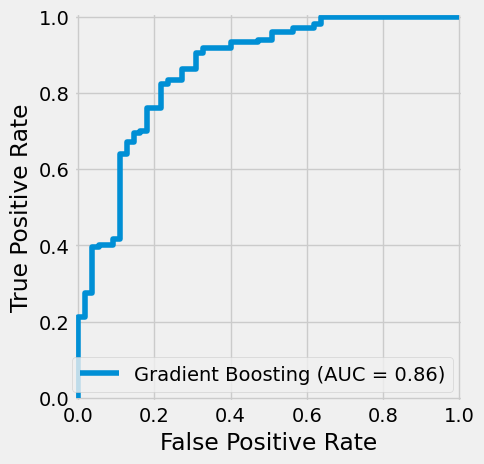

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, boost_pred_proba)
auc_score = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_score, estimator_name='Gradient Boosting')
display.plot()
plt.show()

## Your Turn!

We did only a minimal amount of hyperparameter tuning. Try to improve the Boosted Trees model by extending the search space (i.e., more hyperparameters and more candidate values per hyperparameter).